# Prompt-Based Generation

In [17]:
import torch
from torch.utils.data import Dataset, dataloader
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import os
import random

## Data Visualization

### General Information

In [4]:
pd.set_option('display.max_colwidth', None)
data = pd.read_csv("./data/HAM10000_metadata.csv")
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
print(f'{data.shape[0]} samples before dropping patients NaN values')
data = data.dropna()
data = data.reset_index(drop=True)
print(f'{data.shape[0]} samples after dropping patients NaN values')

10015 samples before dropping patients NaN values
9958 samples after dropping patients NaN values


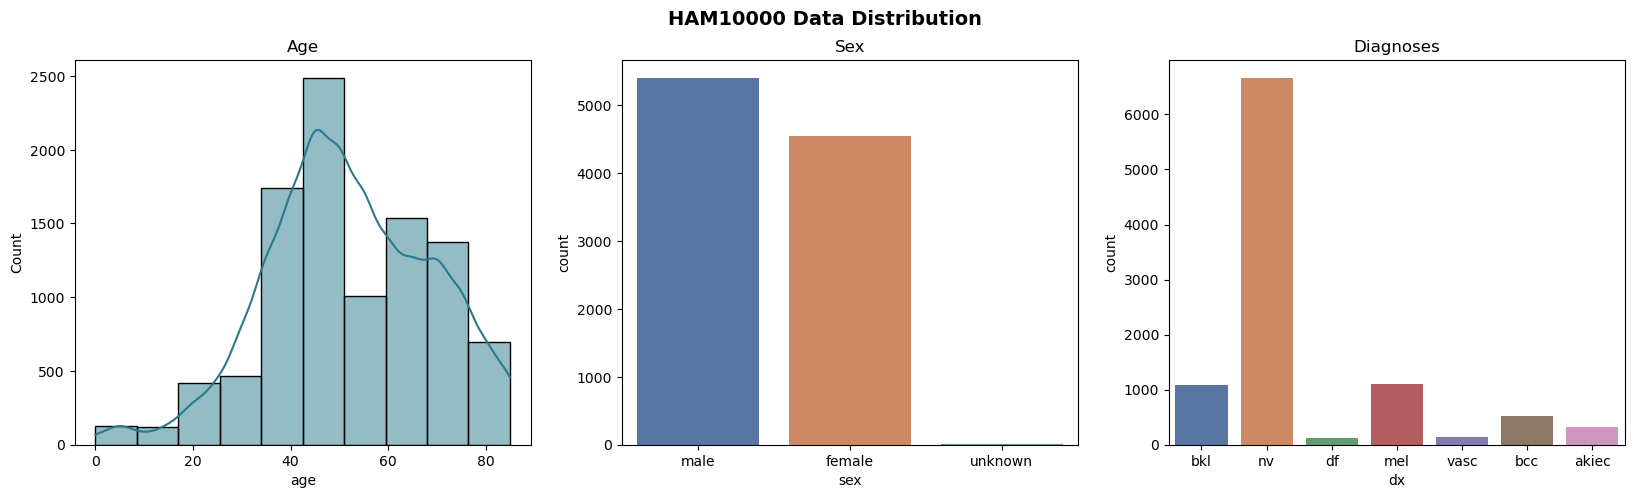

In [6]:
fig, axes = plt.subplots(1,3, figsize=(20,5))

sns.histplot(data=data, bins= 10, x = 'age', kde=True, color=sns.color_palette("crest")[3], ax=axes[0])
axes[0].set_title('Age')

sns.countplot(data=data, x = 'sex', hue='sex', palette='deep', ax=axes[1])
axes[1].set_title("Sex")

sns.countplot(data=data, x = 'dx', palette='deep', hue = 'dx', ax=axes[2])
axes[2].set_title('Diagnoses')

plt.suptitle('HAM10000 Data Distribution', fontweight='bold', fontsize=14)
plt.show()

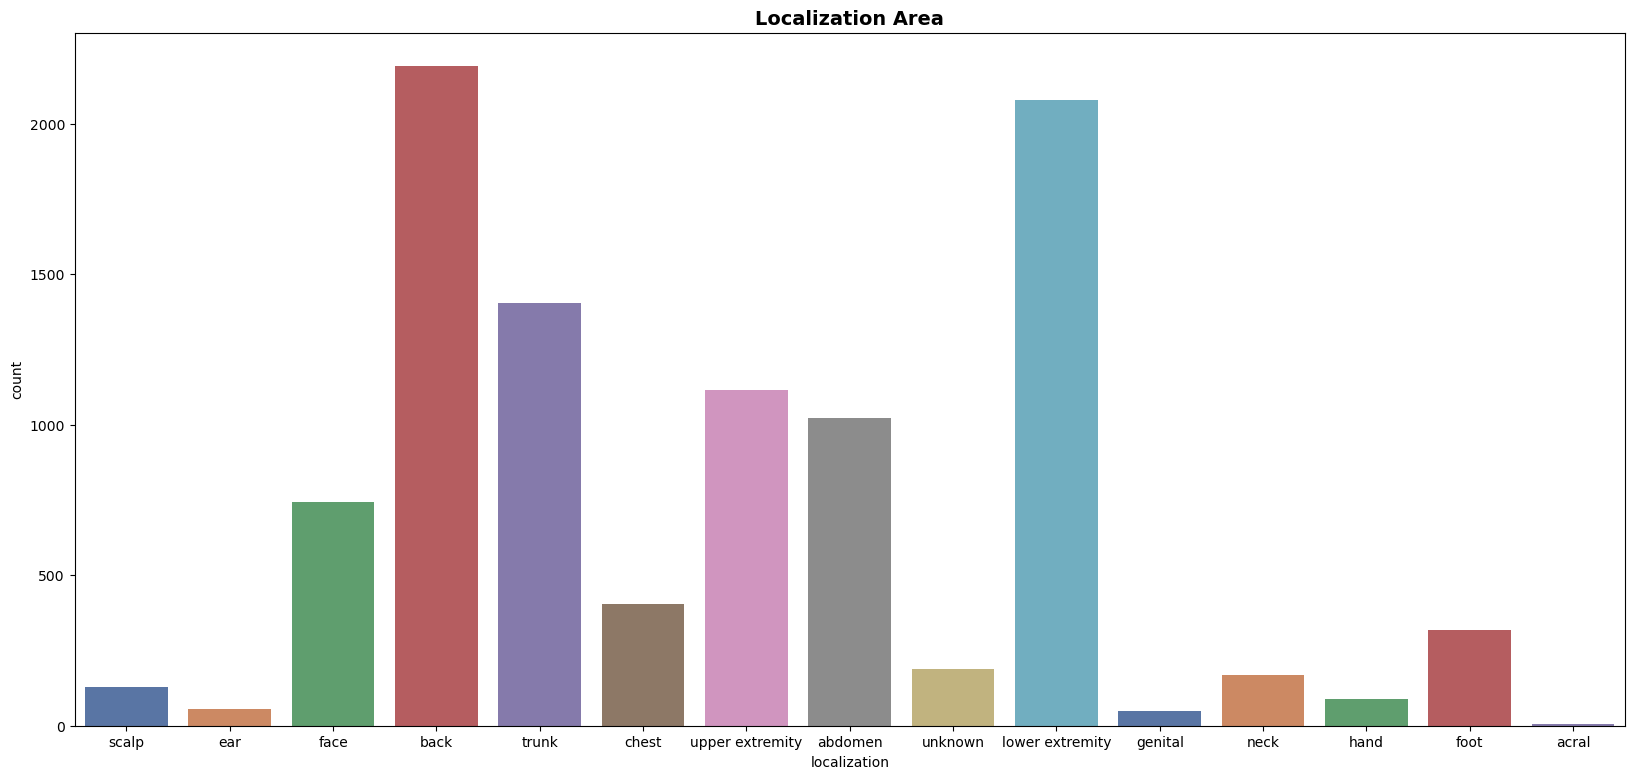

In [7]:
plt.figure(figsize=(20,9))
sns.countplot(data=data, x='localization', palette='deep', hue='localization')
plt.title('Localization Area', fontweight='bold',fontsize=14)
plt.show()

### Display Random Image

In [8]:
index = random.randint(0,data.shape[0])

def display_image(index):
    image_id = data['image_id'][index]
    if not image_id.endswith('.jpg'):
        image_id += '.jpg'
    file1 = os.path.join('data', 'HAM10000_images_part_1', image_id)
    file2 = os.path.join('data', 'HAM10000_images_part_2', image_id)
    
    if os.path.exists(file1):
        return file1
    elif os.path.exists(file2):
        return file2
    else:
        raise FileNotFoundError

image = display_image(index)

In [9]:
def display_metadata(index):
    image_metadata = pd.DataFrame(data.iloc[index,:]).reset_index()
    image_metadata.columns = ['Feature', 'Value']
    return image_metadata

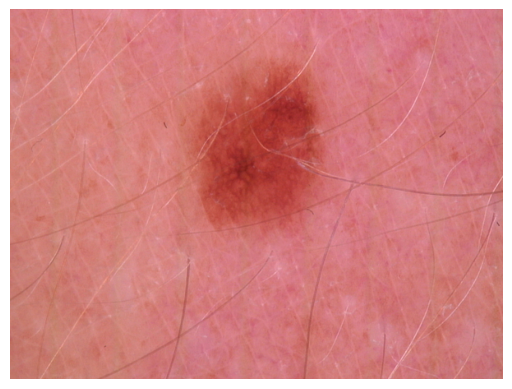

,Feature,Value
0,lesion_id,HAM_0000246
1,image_id,ISIC_0027079
2,dx,nv
3,dx_type,follow_up
4,age,25.0
5,sex,female
6,localization,upper extremity


In [10]:
image = Image.open(image)
plt.imshow(image)
plt.axis('off')
plt.show()
display_metadata(index)


## Prompt Builder

In [11]:
diagnosis_map = {
    'akiec': 'actinic keratosis / Bowen\'s disease',
    'bcc': 'basal cell carcinoma',
    'bkl': 'benign keratosis-like lesion',
    'df': 'dermatofibroma',
    'mel': 'melanoma',
    'nv': 'melanocytic nevus',
    'vasc': 'vascular lesion'
}

In [12]:
prompts = [
    "Dermoscopy image of a {dx} on the {site} of a {age}-year-old {sex}.",
    "Dermoscopic photograph showing a {dx} on the {site} in a {age}-year-old {sex}.",
    "Skin lesion ({dx}) located on the {site} of a {age}-year-old {sex}.",
    "High-resolution dermoscopy of a {dx} on the {site}.",
    "Clinical dermoscopic view of a {dx} on the {site}.",
    "Dermoscopic image presenting a {dx} on the {site}.",
    "Magnified skin image of a {dx} found on the {site}.",
    "Detailed dermoscopy of a {dx} lesion on the {site}.",
    "Macro dermoscopic photograph depicting a {dx} on the {site}.",
    "Skin surface dermoscopy showing a {dx} on the {site}.",
    "Dermoscopic evaluation image of a {dx} on the {site}.",
    "Standardized dermoscopy photograph of a {dx} on the {site}.",
    "Polarized dermoscopy image of a {dx} on the {site}.",
    "Dermoscopy of a {dx} on the {site} in a {age}-year-old {sex}.",
    "Cutaneous {dx} located on the {site} of a {age}-year-old {sex}, dermoscopy image.",
    "Dermoscopic close-up showing a {dx} on the {site} of a {age}-year-old {sex}.",
    "Pigmented lesion ({dx}) on the {site} in a {age}-year-old {sex}, dermoscopic view.",
    "Clinical close-up dermoscopy showing {dx} on the {site}.",
    "{dx} on the {site}, dermoscopy image.",
    "Dermoscopic photo: {dx} on the {site}.",
    "Dermoscopy view of lesion: {dx} on {site}.",
    "Magnified dermoscopy image of {dx} on the {site}.",
    "Diagnostic dermoscopy capture depicting a {dx}.",
    "Dermatology-focused dermoscopic image showing a {dx} lesion.",
    "Dermoscopy of {dx}."
]

In [13]:
def create_prompt(df_row):
    if df_row['localization'] == 'unknown':
        prompt_choice = random.choice(prompts[22:])
    else:
        prompt_choice = random.choice(prompts)
    
    if 'dx' in prompt_choice:
        diagnoses = df_row['dx']
        mapping = diagnosis_map[diagnoses]
        prompt_choice = prompt_choice.replace('{dx}', mapping)
    if 'site' in prompt_choice:
        prompt_choice = prompt_choice.replace('{site}', df_row['localization'])
    if 'age' in prompt_choice:
        prompt_choice = prompt_choice.replace('{age}', str(int(df_row['age'])))
    if 'sex' in prompt_choice:
        prompt_choice = prompt_choice.replace('{sex}', df_row['sex'])
    
    return prompt_choice

In [14]:
row, col = data.shape
data['Prompt'] = np.full((row), 'NA')

for idx in range(row):
    patient = data.iloc[idx,:]
    prompt = create_prompt(patient)
    data.loc[idx, 'Prompt'] = prompt
    
data.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,Prompt
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Dermoscopic photograph showing a benign keratosis-like lesion on the scalp in a 80-year-old male.
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Dermoscopy view of lesion: benign keratosis-like lesion on scalp.
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Dermoscopy image of a benign keratosis-like lesion on the scalp of a 80-year-old male.
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,"benign keratosis-like lesion on the scalp, dermoscopy image."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Dermoscopic photograph showing a benign keratosis-like lesion on the ear in a 75-year-old male.
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,Dermoscopic photo: benign keratosis-like lesion on the ear.
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,Skin surface dermoscopy showing a benign keratosis-like lesion on the face.
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,Macro dermoscopic photograph depicting a benign keratosis-like lesion on the face.
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,Macro dermoscopic photograph depicting a benign keratosis-like lesion on the back.
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,Dermoscopic photograph showing a benign keratosis-like lesion on the back in a 70-year-old female.


,Feature,Value
0,lesion_id,HAM_0000246
1,image_id,ISIC_0027079
2,dx,nv
3,dx_type,follow_up
4,age,25.0
5,sex,female
6,localization,upper extremity
7,Prompt,Dermatology-focused dermoscopic image showing a melanocytic nevus lesion.


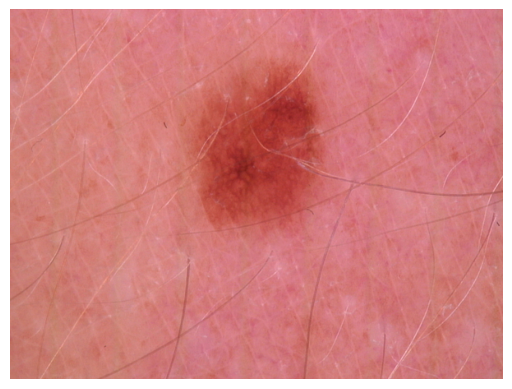

In [15]:
image = display_image(index)
image = Image.open(image)
plt.imshow(image)
plt.axis('off')
display_metadata(index)

## Dataset

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
model = "runwayml/stable-diffusion-v1-5"

pipeline = StableDiffusionPipeline.from_pretrained(
    model,
    torch_dtype = torch.float16
).to(device)

In [14]:
class HAMPromptDataset(Dataset):
    def __init__(self, folder1, folder2, dataframe, image_processor):
        super().__init__()
        self.dataframe = dataframe
        self.folder1 = folder1
        self.folder2 = folder2
        self.image_processor = image_processor
    
    def __len__(self):
        return self.dataframe.shape[0]
    
    def __getitem__(self, index):
        sample = self.dataframe.iloc[index,:]
        sample_id = sample['image_id']
        if not sample_id.endswith('.jpg'):
            sample_id += '.jpg'
        prompt = sample['Prompt']
        
        path1 = os.path.join(self.folder1, sample_id)
        path2 = os.path.join(self.folder2, sample_id)
        if os.path.exists(path1):
            image_path = path1
        elif os.path.exists(path2):
            image_path = path2
        else:
            raise FileNotFoundError('Sample does not exist')
        
        image = Image.open(image_path).convert('RGB')
        
        processed_image = self.image_processor.preprocess(
            image,
            return_tensors = 'pt'
        )
        pixel_values = processed_image['pixel_values'][0] # since above returns a batch in a dictionary
        

        return {
            'pixel_values': pixel_values,
            'prompt': prompt
        }
        
        

In [ ]:
dataset = HAMPromptDataset('data/HAM10000_images_part_1', 'data/HAM10000_images_part_2', data, pipeline.image_processor)
dataloader = dataloader(dataset, batch_size = 4, shuffle=True, num_workers = 4, pin_memory=True)

In [ ]:
LoraConfig = LoraConfig(
    r = 8,
    lora_alpha = 16,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
)

## Model

## Diffusion Machinery

## U-Net Architecture